数据列名: ['GridID', 'year', 'lon', 'lat', 'cropland_percent', 'forest_percent', 'impervious_surface_percent', 'water_percent', 'ntl_mean', 'area_mn', 'edge_density', 'largest_patch_index', 'number_of_patches', 'patch_density', 'proportion_of_landscape', 'CMRI_mean_mangrove', 'EMVI_mean_mangrove', 'EVI_mean_mangrove', 'MVI_mean_mangrove', 'NDVI_mean_mangrove', 'kNDVI_mean_mangrove', 'mean_annual_temp', 'coldest_month_temp', 'total_annual_precip', 'mean_annual_lst_day', 'mean_annual_sst', 'dist_to_coast', 'water_occurrence', 'population_mean', 'MHI', 'mangrove_class']

数据前5行:
       GridID  year         lon        lat  cropland_percent  forest_percent  \
0  HEX_000000  2000  112.334416  21.956900         15.012346       84.148148   
1  HEX_000001  2000  112.334416  21.971330          4.944376       80.469716   
2  HEX_000002  2000  112.334416  21.985759         12.149918       84.555189   
3  HEX_000003  2000  112.347891  21.964116         39.530091       52.473207   
4  HEX_000004  2000  1

C:\Users\jr\AppData\Local\Temp\ipykernel_29532\2793414568.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.stripplot(x='year_str', y='MHI', data=df, palette=pal,


Raincloud plot 已保存


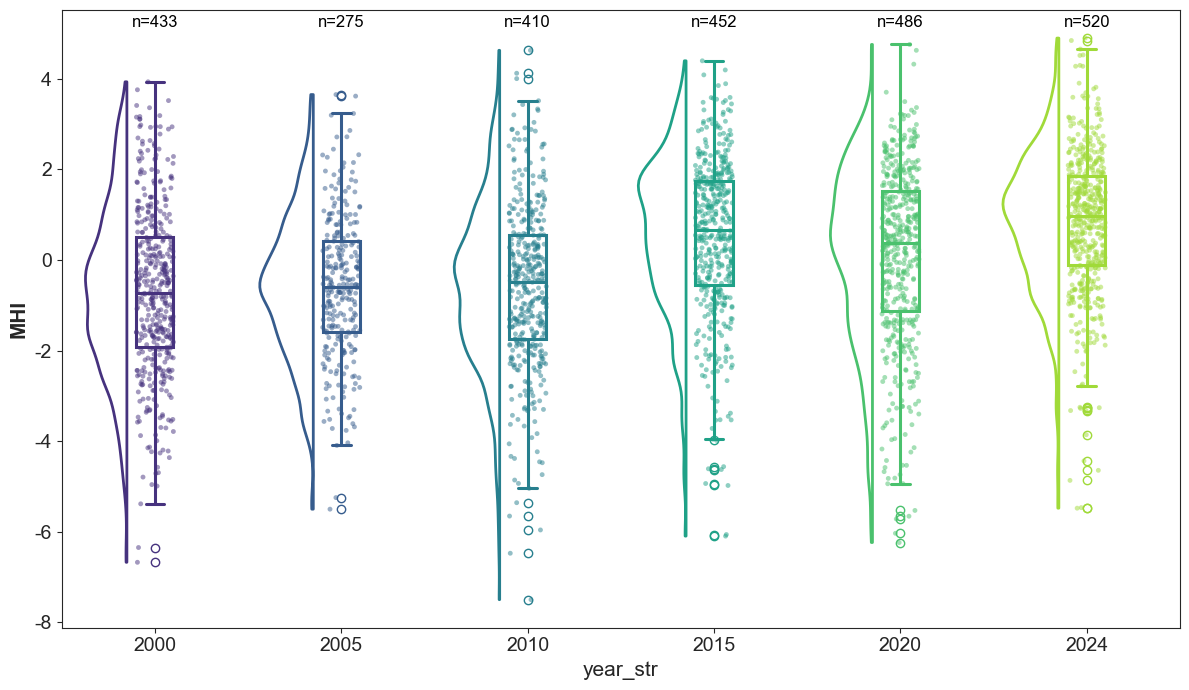

直方图/核密度分布已保存


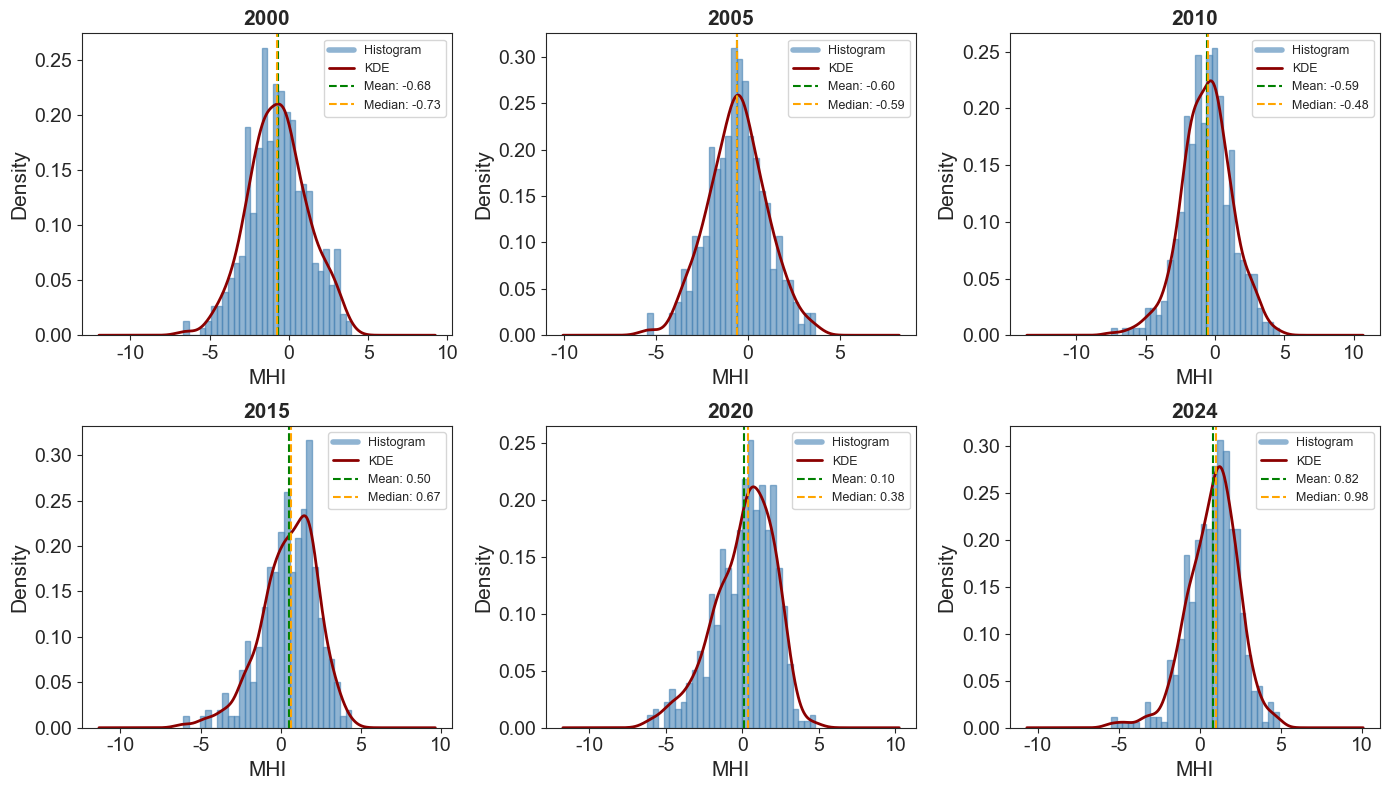


MHI 统计摘要

年份: 2000
  样本数: 433
  均值: -0.6842
  中位数: -0.7347
  标准差: 1.8567
  最小值: -6.6734
  最大值: 3.9308
  25%分位数: -1.9166
  75%分位数: 0.5105

年份: 2005
  样本数: 275
  均值: -0.6015
  中位数: -0.5872
  标准差: 1.5854
  最小值: -5.5010
  最大值: 3.6493
  25%分位数: -1.6011
  75%分位数: 0.4090

年份: 2010
  样本数: 410
  均值: -0.5897
  中位数: -0.4824
  标准差: 1.8110
  最小值: -7.4979
  最大值: 4.6258
  25%分位数: -1.7477
  75%分位数: 0.5429

年份: 2015
  样本数: 452
  均值: 0.5044
  中位数: 0.6679
  标准差: 1.7497
  最小值: -6.0953
  最大值: 4.3946
  25%分位数: -0.5437
  75%分位数: 1.7425

年份: 2020
  样本数: 486
  均值: 0.1029
  中位数: 0.3819
  标准差: 1.9521
  最小值: -6.2370
  最大值: 4.7555
  25%分位数: -1.1175
  75%分位数: 1.5120

年份: 2024
  样本数: 520
  均值: 0.8182
  中位数: 0.9768
  标准差: 1.5625
  最小值: -5.4792
  最大值: 4.8962
  25%分位数: -0.1124
  75%分位数: 1.8446

整体 MHI 统计
总样本数: 2576
均值: -0.0000
中位数: 0.0990
标准差: 1.8621
最小值: -7.4979
最大值: 4.8962


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ptitprince as pt  # 需要安装: pip install ptitprince
from matplotlib.gridspec import GridSpec
sns.set_style("ticks")
# 设置绘图样式
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 16


# 读取数据
data_path = 'final_environmental_vars_with_MHI.csv'
df = pd.read_csv(data_path)

# 检查数据列名
print("数据列名:", df.columns.tolist())
print("\n数据前5行:")
print(df.head())
print(f"\n数据形状: {df.shape}")
print(f"年份范围: {df['year'].min()} - {df['year'].max()}")

# 准备数据 - 将year转换为字符串以便更好地显示
df['year_str'] = df['year'].astype(str)

# --- 图1: Raincloud Plot - 各年份 MHI 分布 ---
fig, ax = plt.subplots(figsize=(12, 7))

# 设置颜色方案
years = sorted(df['year'].unique())
pal = sns.color_palette("viridis", n_colors=len(years))

violin_parts = pt.half_violinplot(x='year_str', y='MHI', data=df, palette=pal, 
                        bw=.2, cut=0., scale="area", width=.6, inner=None)

# 修改半小提琴图的颜色 - 设置边框颜色与填充透明
for i, pc in enumerate(violin_parts.collections):
    pc.set_facecolor('none')  # 内部透明
    pc.set_edgecolor(pal[i])  # 边框颜色与点相同
    pc.set_linewidth(2)       # 边框线宽

# 绘制散点图
ax = sns.stripplot(x='year_str', y='MHI', data=df, palette=pal, 
                   edgecolor="white", size=3.5, jitter=0.1, zorder=0, alpha=0.5)

# 绘制箱线图 - 为每年使用对应的颜色
for i, (year, color) in enumerate(zip(years, pal)):
    year_df = df[df['year'] == year]
    bp = ax.boxplot([year_df['MHI'].dropna()], positions=[i], widths=0.2,
                     showcaps=True, showfliers=True,
                     patch_artist=True,
                     boxprops=dict(facecolor='none', edgecolor=color, linewidth=2.2, zorder=10),
                     whiskerprops=dict(color=color, linewidth=2.2, zorder=10),
                     capprops=dict(color=color, linewidth=2.2, zorder=10),
                     medianprops=dict(color=color, linewidth=2.2, zorder=10),
                     flierprops=dict(markeredgecolor=color, marker='o', markersize=6, 
                                   linestyle='none', markerfacecolor='none', zorder=10))

# 设置X轴标签为年份
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=0)
#ax.set_xlabel('Year', fontsize=15, fontweight='bold')
ax.set_ylabel('MHI', fontsize=15, fontweight='bold')

# 添加样本数标注
for i, year in enumerate(years):
    year_data = df[df['year'] == year]['MHI'].dropna()
    n_samples = len(year_data)
    ax.text(i, ax.get_ylim()[1] * 0.98, f'n={n_samples}', 
            ha='center', va='top', fontsize=12, color='black')

plt.tight_layout()
plt.savefig('mhi_raincloud_by_year.png', dpi=300, bbox_inches='tight')

print("Raincloud plot 已保存")
plt.show()

# --- 图2: 传统直方图/核密度分布 ---
fig1 = plt.figure(figsize=(14, 8))

years = sorted(df['year'].unique())
n_years = len(years)
rows = (n_years + 2) // 3
cols = min(3, n_years)

for idx, year in enumerate(years, 1):
    ax = plt.subplot(rows, cols, idx)
    year_data = df[df['year'] == year]['MHI'].dropna()
    
    ax.hist(year_data, bins=30, density=True, alpha=0.6, 
            color='steelblue', edgecolor='steelblue', label='Histogram')
    
    if len(year_data) > 1:
        year_data.plot.kde(ax=ax, color='darkred', linewidth=2, label='KDE')
    
    ax.set_xlabel('MHI', fontsize=15)
    ax.set_ylabel('Density', fontsize=15)
    ax.set_title(f'{year}', fontsize=15, fontweight='bold')

    
    mean_val = year_data.mean()
    median_val = year_data.median()
    ax.axvline(mean_val, color='green', linestyle='--', linewidth=1.5)
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=1.5)
    
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='steelblue', lw=4, alpha=0.6, label='Histogram'),
        Line2D([0], [0], color='darkred', lw=2, label='KDE'),
        Line2D([0], [0], color='green', lw=1.5, linestyle='--', label=f'Mean: {mean_val:.2f}'),
        Line2D([0], [0], color='orange', lw=1.5, linestyle='--', label=f'Median: {median_val:.2f}')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('mhi_distribution_by_year.png', dpi=600, bbox_inches='tight')

print("直方图/核密度分布已保存")
plt.show()


# --- 打印统计摘要 ---
print("\n" + "="*50)
print("MHI 统计摘要")
print("="*50)

for year in sorted(df['year'].unique()):
    year_data = df[df['year'] == year]['MHI'].dropna()
    print(f"\n年份: {year}")
    print(f"  样本数: {len(year_data)}")
    print(f"  均值: {year_data.mean():.4f}")
    print(f"  中位数: {year_data.median():.4f}")
    print(f"  标准差: {year_data.std():.4f}")
    print(f"  最小值: {year_data.min():.4f}")
    print(f"  最大值: {year_data.max():.4f}")
    print(f"  25%分位数: {year_data.quantile(0.25):.4f}")
    print(f"  75%分位数: {year_data.quantile(0.75):.4f}")

print("\n" + "="*50)
print("整体 MHI 统计")
print("="*50)
mhi_all = df['MHI'].dropna()
print(f"总样本数: {len(mhi_all)}")
print(f"均值: {mhi_all.mean():.4f}")
print(f"中位数: {mhi_all.median():.4f}")
print(f"标准差: {mhi_all.std():.4f}")
print(f"最小值: {mhi_all.min():.4f}")
print(f"最大值: {mhi_all.max():.4f}")